In [20]:
import pymcel as pc

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go

In [22]:
sistema = [ #dos particulas, unidades canonicas
    dict(m = 1, r = [0,0,0], v = [0,0,0]),
    dict(m = 1, r = [1,0,0], v = [0,1,0])
]

In [23]:
ts = np.linspace(0, 10, 100) #tiempos del futuro
rs, vs, rps, vps, constantes = pc.ncuerpos_solucion(sistema, ts)
#type(solucion)

In [24]:
pc.ncuerpos_solucion?

Signature: pc.ncuerpos_solucion(sistema, ts)
Docstring:
Resuelve el problema N-cuerpos y calcula constantes.

Parameters
----------
sistema : list[dict]
    Lista de particulas con `m`, `r`, `v`. Cada particula es un
    diccionario con:

    - `m`: masa (o parametro gravitacional)
    - `r`: posicion inicial como iterable de 3 componentes
    - `v`: velocidad inicial como iterable de 3 componentes
ts : numpy.ndarray
    Tiempos de integracion.

    Returns
    -------
    tuple
            `(rs, vs, rps, vps, constantes)` donde:

            - `rs`, `vs`: arreglos con forma `(N, Nt, 3)` para posiciones y
                velocidades absolutas.
            - `rps`, `vps`: arreglos con forma `(N, Nt, 3)` para posiciones y
                velocidades relativas al centro de masa.
            - `constantes`: diccionario con constantes de movimiento y series
                asociadas (`M`, `RCM`, `PCM`, `L`, `K`, `U`, `E`).

Examples
--------
>>> sistema = [
...     dict(m=1.0, r=[-0.5, 0.0,

In [25]:
rs.shape #2 particulas, 100 tiempos, 3 coordenadas cada una, cubo de datos

(2, 100, 3)

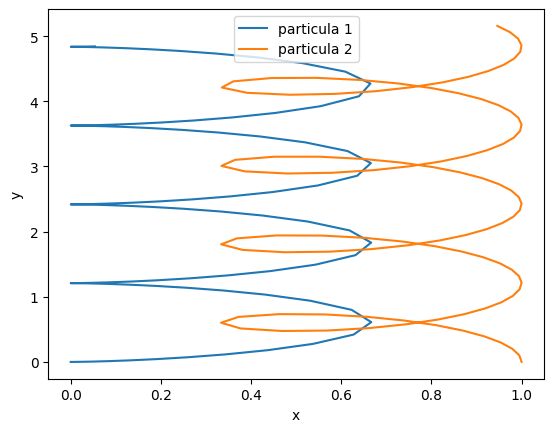

In [26]:
plt.plot(rs[0,:,0], rs[0,:,1], label='particula 1') #solo en x y y, no se ven elipses
plt.plot(rs[1,:,0], rs[1,:,1], label='particula 2')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

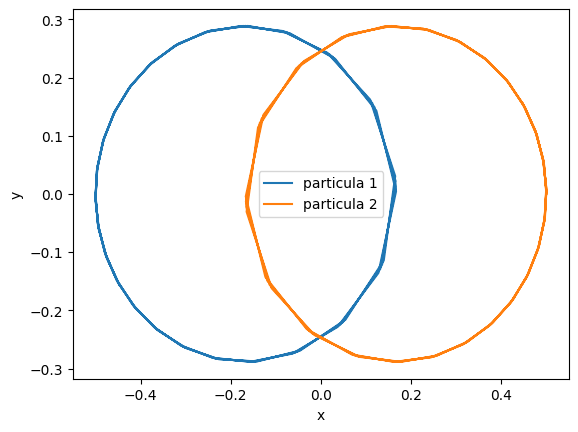

In [27]:
plt.plot(rps[0,:,0], rps[0,:,1], label='particula 1') #solo en x y y, respecto al centro de masa, se ven elipses
plt.plot(rps[1,:,0], rps[1,:,1], label='particula 2')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

##Cuadraturas 
##Momento lineal total


In [28]:
suma = 0
for i in range(2):
    suma += sistema[i]["m"] * vs[i,0,:]

suma

array([0., 1., 0.])

In [29]:
suma_t = 0
for i in range(2):
    suma_t += sistema[i]["m"] * vs[i,12,:]

suma_t #se conserva el momento

array([0., 1., 0.])

#momento angular 

In [30]:
suma = 0
for i in range(2):
    suma += sistema[i]["m"] * np.cross(rs[i,0,:], vs[i,0,:])

suma

array([0., 0., 1.])

In [31]:
sumat_t = 0
for i in range(2):
  sumat_t += sistema[i]["m"] * np.cross(rs[i,50,:], vs[i,50,:])

sumat_t

array([0.        , 0.        , 0.99999978])

In [34]:
sistema[0]["m"] * vs[0] + sistema[1]["m"] * vs[1] 

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1

In [36]:
suma_np = np.einsum('i,ijk->jk', np.array([p["m"] for p in sistema]), vs[:len(sistema)])
suma_np

array([[0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1., 0.],
       [0., 1